In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\craft\AppData\Local\Temp\ipykernel_16700\996171293.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=province_counts.index, y=province_counts.values, palette='Set2')


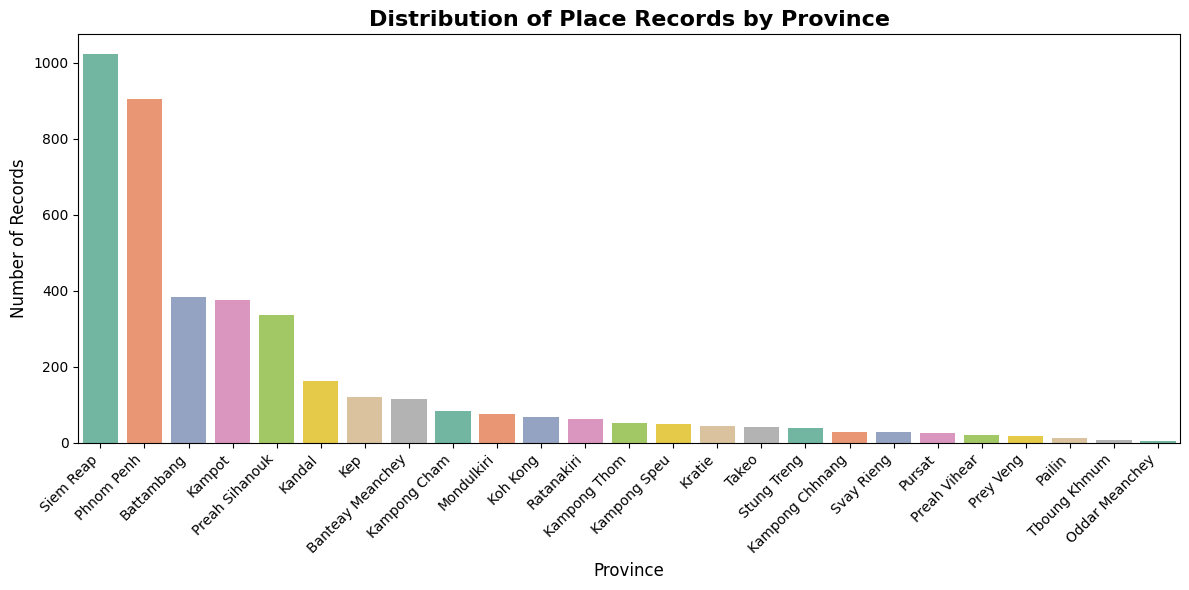

province
Siem Reap           1023
Phnom Penh           904
Battambang           383
Kampot               374
Preah Sihanouk       337
Kandal               162
Kep                  119
Banteay Meanchey     114
Kampong Cham          84
Mondulkiri            75
Koh Kong              67
Ratanakiri            63
Kampong Thom          52
Kampong Speu          48
Kratie                43
Takeo                 40
Stung Treng           39
Kampong Chhnang       29
Svay Rieng            27
Pursat                24
Preah Vihear          20
Prey Veng             17
Pailin                12
Tboung Khmum           8
Oddar Meanchey         5
Name: count, dtype: int64


In [9]:

# Load the data
df = pd.read_csv('../../backend/data/cleaned_merged_data.csv')

# Count records by province
province_counts = df['province'].value_counts().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=province_counts.index, y=province_counts.values, palette='Set2')
plt.title('Distribution of Place Records by Province', fontsize=16, fontweight='bold')
plt.xlabel('Province', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display counts
print(province_counts)

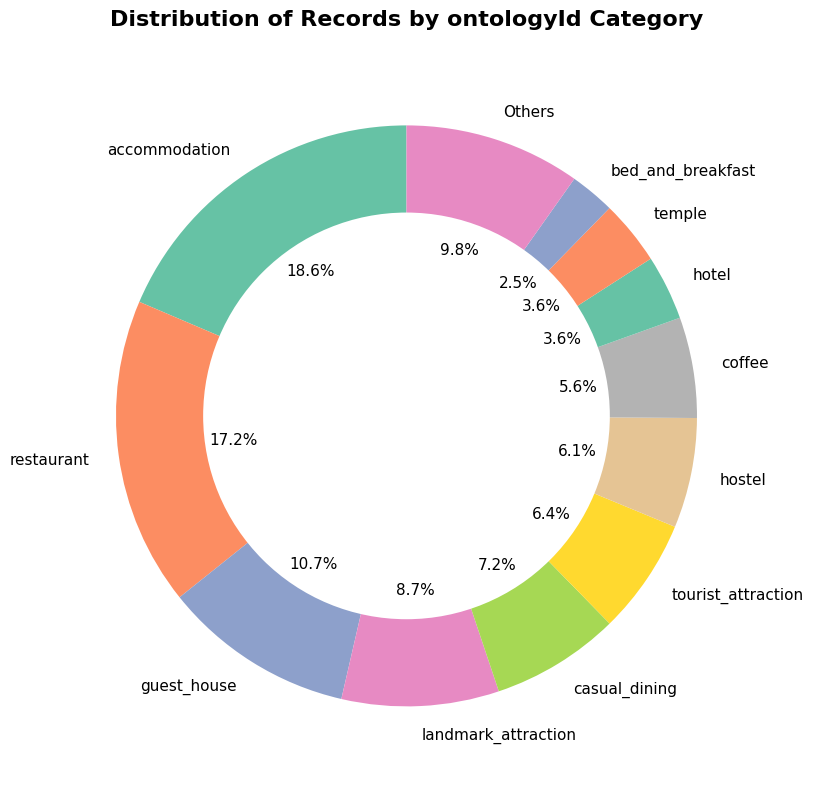

Total categories: 45
Displayed categories: 12
ontologyId
accommodation          756
restaurant             698
guest_house            434
landmark_attraction    356
casual_dining          292
tourist_attraction     262
hostel                 249
coffee                 228
hotel                  147
temple                 146
bed_and_breakfast      102
Others                 399
Name: count, dtype: int64


In [12]:
# Count records by ontologyId category
ontology_counts = df['ontologyId'].value_counts()

# Group smaller categories (less than 2% of total) into "Others"
total = ontology_counts.sum()
threshold = total * 0.02  # 2% threshold
main_categories = ontology_counts[ontology_counts >= threshold]
other_count = ontology_counts[ontology_counts < threshold].sum()

if other_count > 0:
    main_categories['Others'] = other_count

# Create donut chart with matching color palette
fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette('Set2', len(main_categories))
wedges, texts, autotexts = ax.pie(main_categories.values, 
                                    labels=main_categories.index,
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    startangle=90,
                                    textprops={'fontsize': 11})

# Create donut effect (add white circle in center)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

plt.title('Distribution of Records by ontologyId Category', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Display counts
print(f"Total categories: {len(ontology_counts)}")
print(f"Displayed categories: {len(main_categories)}")
print(main_categories)